<a href="https://colab.research.google.com/github/AbidbinAzhar/Fake-News-Detection-using-ML-and-NLP/blob/main/Fake-News-Detection-using-ML-and-NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objective

**Objective:** Build a machine learning model to classify news articles as Real or Fake using NLP techniques, compare multiple classifiers, and evaluate the best model following a reproducible 70:10:20 train-validation-test workflow.

# Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import random
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# Setting Random Seed for Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Data Collection

In [ ]:
#Loading the dataset into Notebook
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

In [ ]:
#Displaying first few records
fake_df.head()
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
#Displaying datasets shapes
print("Fake News:", fake_df.shape)
print("True News:", true_df.shape)

Fake News: (23481, 4)
True News: (21417, 4)


In [ ]:
#Examining Columns for cross-check
print(fake_df.columns)
print(true_df.columns)

Index(['title', 'text', 'subject', 'date'], dtype='object')
Index(['title', 'text', 'subject', 'date'], dtype='object')


# Exploratory Data Analysis

**Purpose:** Explore the dataset to understand its structure, class distribution, missing values, duplicates, and other characteristics before preprocessing.

In [ ]:
#Checking dataset dimensions, data types, and non-null values
print("Fake News Dataset Shape:", fake_df.shape)
print("True News Dataset Shape:", true_df.shape)

print("\nFake News Info:")
fake_df.info()

print("\nTrue News Info:")
true_df.info()

Fake News Dataset Shape: (23481, 4)
True News Dataset Shape: (21417, 4)

Fake News Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB

True News Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [ ]:
#Displaying sample records to verify dataset loaded correctly
fake_df.head(3)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"


In [ ]:
#Displaying sample records to verify dataset loaded correctly
true_df.head(3)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"


In [ ]:
#Checking Missing Values
print("Fake News Missing Values:")
print(fake_df.isnull().sum())

print("\nTrue News Missing Values:")
print(true_df.isnull().sum())

Fake News Missing Values:
title      0
text       0
subject    0
date       0
dtype: int64

True News Missing Values:
title      0
text       0
subject    0
date       0
dtype: int64


In [ ]:
#Checking duplicate records
print("Fake Duplicates:", fake_df.duplicated().sum())
print("True Duplicates:", true_df.duplicated().sum())

Fake Duplicates: 3
True Duplicates: 206


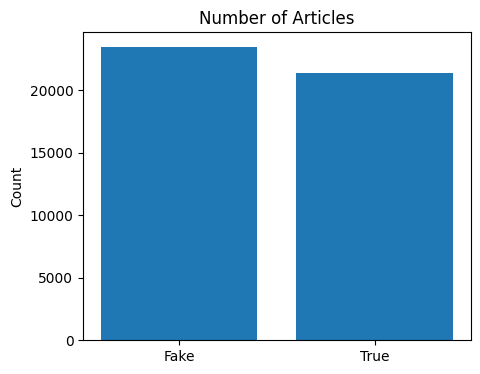

In [ ]:
#Dataset Size Comparison
import matplotlib.pyplot as plt

sizes = [len(fake_df), len(true_df)]
labels = ["Fake", "True"]

plt.figure(figsize=(5,4))
plt.bar(labels, sizes)
plt.title("Number of Articles")
plt.ylabel("Count")
plt.show()

In [ ]:
#Subject Distribution for dataset bias
print(fake_df["subject"].value_counts())
print(true_df["subject"].value_counts())

subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64
subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64


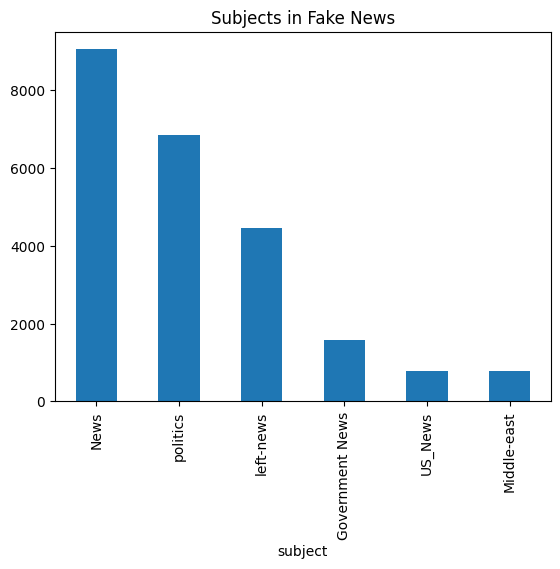

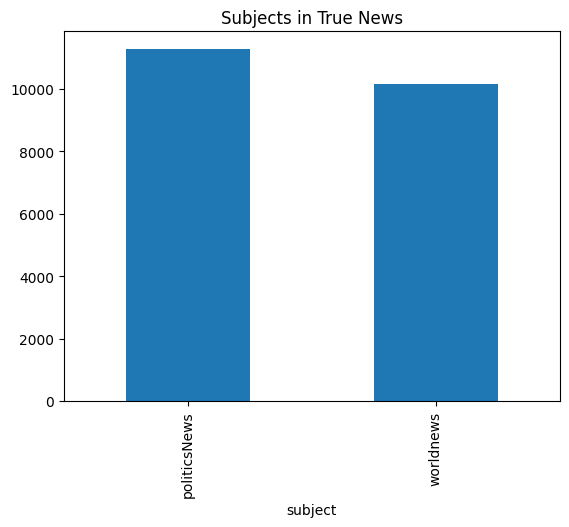

In [ ]:
#Vusualizing Subject Distribution
fake_df["subject"].value_counts().plot(kind="bar")
plt.title("Subjects in Fake News")
plt.show()

true_df["subject"].value_counts().plot(kind="bar")
plt.title("Subjects in True News")
plt.show()

In [ ]:
#News Article Length Analysis
fake_df["text_length"] = fake_df["text"].apply(lambda x: len(str(x).split()))
true_df["text_length"] = true_df["text"].apply(lambda x: len(str(x).split()))

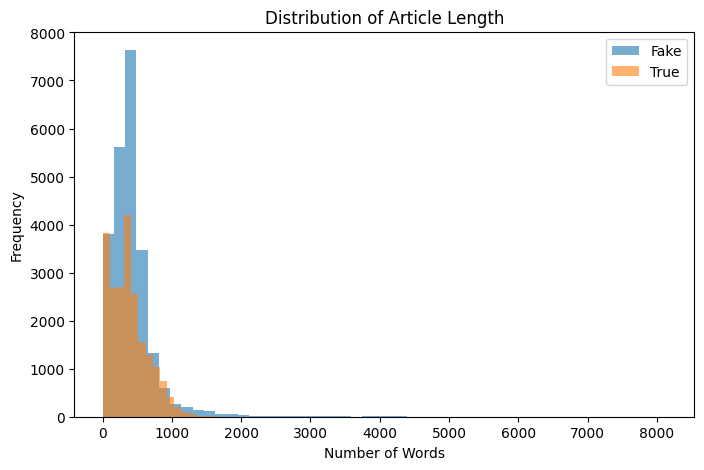

In [ ]:
#Visualizing Article Length Size
plt.figure(figsize=(8,5))

plt.hist(fake_df["text_length"], bins=50, alpha=0.6, label="Fake")
plt.hist(true_df["text_length"], bins=50, alpha=0.6, label="True")

plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Article Length")
plt.legend()

plt.show()

In [ ]:
#Performing Basic Statistics on Fake news dataset
fake_df["text_length"].describe()

,text_length
count,23481.000000
mean,423.197905
std,408.388890
min,0.000000
25%,240.000000
50%,363.000000
75%,506.000000
max,8135.000000


In [ ]:
#Performing Basic Statistics on True news dataset
true_df["text_length"].describe()

,text_length
count,21417.000000
mean,385.640099
std,274.006204
min,0.000000
25%,148.000000
50%,359.000000
75%,525.000000
max,5172.000000


# Data Preprocessing


**Purpose:** Improve data quality by handling missing values, removing duplicates, creating class labels, combining text fields, and cleaning the text to prepare it for feature extraction and model training.

In [ ]:
#Assigning the labels for the datasets
fake_df["label"] = 0
true_df["label"] = 1

In [ ]:
#Merging both the datasets
df = pd.concat([fake_df, true_df], ignore_index=True)

In [ ]:
#Verifying the merge dataset
df.shape

(44898, 6)

In [ ]:
#Cross checking the data
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())

(44898, 6)
title          0
text           0
subject        0
date           0
text_length    0
label          0
dtype: int64
209


In [ ]:
#Shuffling the dataset, for mix of True and Fake news
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

In [ ]:
#Removing Duplicate Articles
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

209


In [ ]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:\n", df.isnull().sum())
print(df["label"].value_counts())

Shape: (44689, 6)
Duplicate rows: 0
Missing values:
 title          0
text           0
subject        0
date           0
text_length    0
label          0
dtype: int64
label
0    23478
1    21211
Name: count, dtype: int64


In [ ]:
#Dropping text_length column
df.drop(columns=["text_length"], inplace=True)

In [ ]:
#Missing Value Verification
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [ ]:
#Combining Title and Body
df["content"] = df["title"] + " " + df["text"]

In [ ]:
#Cleaning the text(Lowercase, Removing URLs, HTML, punctuation/numbers, and normalizing whitespace)
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Train-Validation-Test Split

**Purpose:** Split the dataset into training (70%), validation (10%), and testing (20%) sets. Stratified sampling is used to maintain the original class distribution across all subsets.

In [ ]:
#Defining Feature and Target
X = df["content"]
y = df["label"]

In [ ]:
#Creating Test Set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

In [ ]:
#Creating Validation Set
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    random_state=SEED,
    stratify=y_train_val
)

In [ ]:
#Verifying Split Sizes
print("Training Set :", X_train.shape)
print("Validation Set:", X_val.shape)
print("Test Set :", X_test.shape)

Training Set : (31282,)
Validation Set: (4469,)
Test Set : (8938,)


In [ ]:
#Verifying CLass Distribution
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

label
0    0.52535
1    0.47465
Name: proportion, dtype: float64
label
0    0.525397
1    0.474603
Name: proportion, dtype: float64
label
0    0.525397
1    0.474603
Name: proportion, dtype: float64


# Feature Engineering

**Purpose:** Convert cleaned text into numerical features using TF-IDF, which represents each document based on the importance of its words. This allows machine learning models to process textual data effectively.

In [ ]:
#Initializing TF-IDF
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=50000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [ ]:
#Fitting only in Training Data
X_train_tfidf = tfidf.fit_transform(X_train)

In [ ]:
#Transforming Validation Data
X_val_tfidf = tfidf.transform(X_val)

In [ ]:
#Transforming Test Data
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
#Verifying dimensions
print("Training:", X_train_tfidf.shape)
print("Validation:", X_val_tfidf.shape)
print("Testing:", X_test_tfidf.shape)

Training: (31282, 50000)
Validation: (4469, 50000)
Testing: (8938, 50000)


# Model Building

**Purpose:** Train multiple classifiers and compare their performance. Multinomial Naive Bayes, Logistic Regression, and Linear SVM are selected as they are well-suited for high-dimensional TF-IDF text classification.

In [ ]:
#MOdel1: Multinomial Naive Bayesand Initializing
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()

#Train
nb_model.fit(X_train_tfidf, y_train)

#Predict on Validation Set
y_val_pred_nb = nb_model.predict(X_val_tfidf)

In [ ]:
#MOdel2: LOgistic Regression
from sklearn.linear_model import LogisticRegression

#Initialize
lr_model = LogisticRegression(
    random_state=SEED,
    max_iter=1000
)

#Train
lr_model.fit(X_train_tfidf, y_train)

#Prediction on Validation Set
y_val_pred_lr = lr_model.predict(X_val_tfidf)

In [ ]:
#MOdel3: Linear SVM
from sklearn.svm import LinearSVC

#Initialize
svm_model = LinearSVC(
    random_state=SEED
)

#Train
svm_model.fit(X_train_tfidf, y_train)

#Prediction on Validation Set
y_val_pred_svm = svm_model.predict(X_val_tfidf)

# Model Evaluation and Results

**Purpose:** Evaluate each model on the validation set using Accuracy, Precision, Recall, F1-score, and ROC-AUC to identify the best-performing classifier.

In [ ]:
#Importing evaluation library required
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)


Accuracy: 0.9566
Precision: 0.9590
Recall: 0.9491
F1 Score: 0.9540
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      2348
           1       0.96      0.95      0.95      2121

    accuracy                           0.96      4469
   macro avg       0.96      0.96      0.96      4469
weighted avg       0.96      0.96      0.96      4469



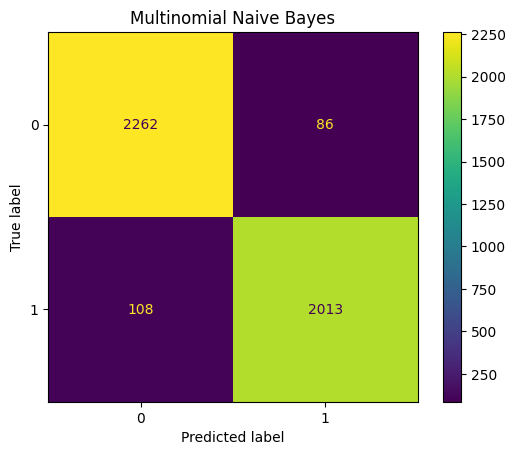

ROC-AUC: 0.9898


In [ ]:
#Evaluating MUltinomail NAive Bayes on various metrics

#Accuracy
nb_accuracy = accuracy_score(y_val, y_val_pred_nb)
print(f"Accuracy: {nb_accuracy:.4f}")

#Precision
nb_precision = precision_score(y_val, y_val_pred_nb)
print(f"Precision: {nb_precision:.4f}")

#Recall
nb_recall = recall_score(y_val, y_val_pred_nb)
print(f"Recall: {nb_recall:.4f}")

#F1-score
nb_f1 = f1_score(y_val, y_val_pred_nb)
print(f"F1 Score: {nb_f1:.4f}")

#Classification Report
print(classification_report(y_val, y_val_pred_nb))

#Confusion Matrix
cm_nb = confusion_matrix(y_val, y_val_pred_nb)
ConfusionMatrixDisplay(cm_nb).plot()
plt.title("Multinomial Naive Bayes")
plt.show()

#ROC-AUC
y_val_prob_nb = nb_model.predict_proba(X_val_tfidf)[:, 1]
nb_auc = roc_auc_score(y_val, y_val_prob_nb)
print(f"ROC-AUC: {nb_auc:.4f}")


Accuracy: 0.9908
Precision: 0.9892
Recall: 0.9915
F1 Score: 0.9903

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2348
           1       0.99      0.99      0.99      2121

    accuracy                           0.99      4469
   macro avg       0.99      0.99      0.99      4469
weighted avg       0.99      0.99      0.99      4469



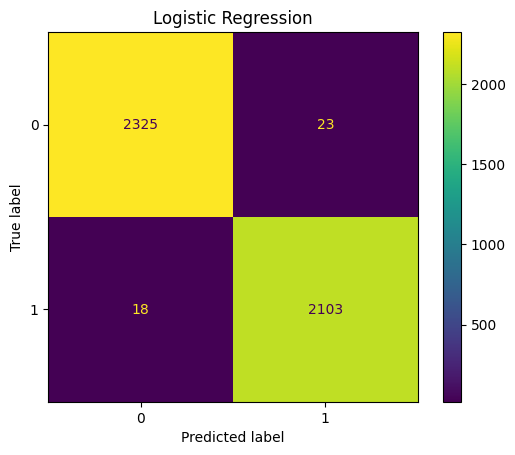

ROC-AUC: 0.9990


In [ ]:
#Evaluating Logistic Regression on various metrics

#Accuracy
lr_accuracy = accuracy_score(y_val, y_val_pred_lr)
print(f"Accuracy: {lr_accuracy:.4f}")

#Precision
lr_precision = precision_score(y_val, y_val_pred_lr)
print(f"Precision: {lr_precision:.4f}")

#Recall
lr_recall = recall_score(y_val, y_val_pred_lr)
print(f"Recall: {lr_recall:.4f}")

#F1 Score
lr_f1 = f1_score(y_val, y_val_pred_lr)
print(f"F1 Score: {lr_f1:.4f}")

#Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_lr))

#Confusion Matrix
cm_lr = confusion_matrix(y_val, y_val_pred_lr)
ConfusionMatrixDisplay(cm_lr).plot()
plt.title("Logistic Regression")
plt.show()

#ROC-AUC
y_val_prob_lr = lr_model.predict_proba(X_val_tfidf)[:, 1]
lr_auc = roc_auc_score(y_val, y_val_prob_lr)
print(f"ROC-AUC: {lr_auc:.4f}")

Accuracy: 0.9966
Precision: 0.9967
Recall: 0.9962
F1 Score: 0.9965

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2348
           1       1.00      1.00      1.00      2121

    accuracy                           1.00      4469
   macro avg       1.00      1.00      1.00      4469
weighted avg       1.00      1.00      1.00      4469



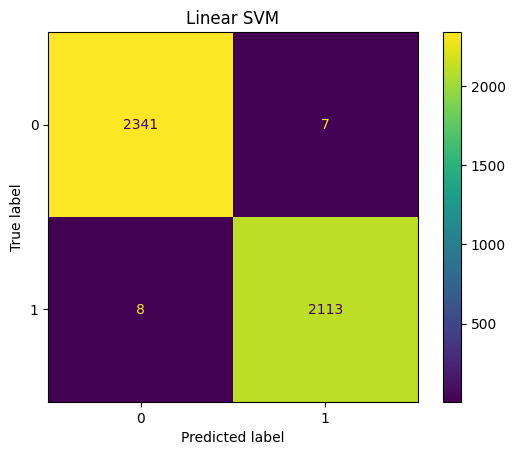

ROC-AUC: 0.9999


In [ ]:
#Evaluating Linear SVM on various metrics

#Accuracy
svm_accuracy = accuracy_score(y_val, y_val_pred_svm)
print(f"Accuracy: {svm_accuracy:.4f}")

#Precision
svm_precision = precision_score(y_val, y_val_pred_svm)
print(f"Precision: {svm_precision:.4f}")

#Recall
svm_recall = recall_score(y_val, y_val_pred_svm)
print(f"Recall: {svm_recall:.4f}")

#F1 Score
svm_f1 = f1_score(y_val, y_val_pred_svm)
print(f"F1 Score: {svm_f1:.4f}")

#Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_svm))

#Confusion Matrix
cm_svm = confusion_matrix(y_val, y_val_pred_svm)
ConfusionMatrixDisplay(cm_svm).plot()
plt.title("Linear SVM")
plt.show()

#ROC-AUC using decision function
svm_scores = svm_model.decision_function(X_val_tfidf)
svm_auc = roc_auc_score(y_val, svm_scores)
print(f"ROC-AUC: {svm_auc:.4f}")

**Observation:** The performance of all models is compared to select the most suitable classifier based on validation results.

In [ ]:
#Model Comparison
comparison_df = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy,
        svm_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision,
        svm_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall,
        svm_recall
    ],
    "F1-Score": [
        nb_f1,
        lr_f1,
        svm_f1
    ],
    "ROC-AUC": [
        nb_auc,
        lr_auc,
        svm_auc
    ]
})

comparison_df = comparison_df.sort_values(
    by="F1-Score",
    ascending=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Linear SVM,0.996644,0.996698,0.996228,0.996463,0.999893
1,Logistic Regression,0.990826,0.989182,0.991513,0.990346,0.998959
0,Multinomial Naive Bayes,0.956590,0.959028,0.949081,0.954028,0.989828


In [ ]:
best_model = svm_model
best_model_name = "Linear SVM"
print(f"Best Model: {best_model_name}")

Best Model: Linear SVM


**Purpose:** The best-performing model is evaluated on the unseen test set to measure its final generalization performance.

# Final Test Evaluation


**Purpose:** Evaluate the selected model on the test dataset using the same performance metrics to obtain an unbiased estimate of its effectiveness.

In [ ]:
#Predicting on Test Set
y_test_pred = best_model.predict(X_test_tfidf)

Accuracy: 0.9956
Precision: 0.9941
Recall: 0.9967
F1 Score: 0.9954

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4696
           1       0.99      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



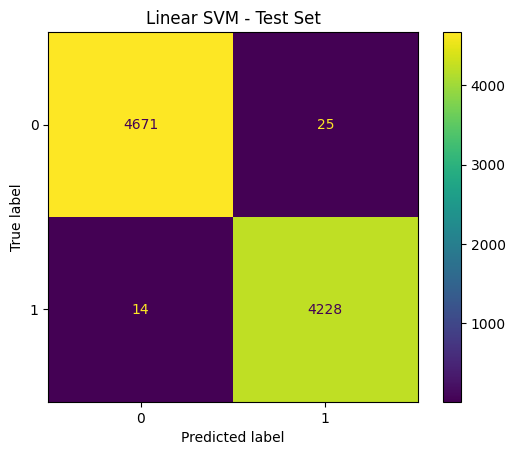

ROC-AUC: 0.9999


In [ ]:
#Evaluating the result

#Accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy: {test_accuracy:.4f}")

#Precision
test_precision = precision_score(y_test, y_test_pred)
print(f"Precision: {test_precision:.4f}")

#Recall
test_recall = recall_score(y_test, y_test_pred)
print(f"Recall: {test_recall:.4f}")

#F1 Score
test_f1 = f1_score(y_test, y_test_pred)
print(f"F1 Score: {test_f1:.4f}")

#Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm_test).plot()
plt.title("Linear SVM - Test Set")
plt.show()

#ROC-AUC
test_scores = best_model.decision_function(X_test_tfidf)
test_auc = roc_auc_score(y_test, test_scores)
print(f"ROC-AUC: {test_auc:.4f}")

In [ ]:
#Creating Summary Table for Better Understanding
test_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Value": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_auc
    ]
})

test_results

,Metric,Value
0,Accuracy,0.995637
1,Precision,0.994122
2,Recall,0.996700
3,F1-Score,0.995409
4,ROC-AUC,0.999869


# Error Analysis

**Purpose:** Analyze misclassified samples to understand the model's limitations and identify cases where predictions were incorrect.

In [ ]:
#Identifying misclassified test samples
misclassified = pd.DataFrame({
    "Text": X_test.reset_index(drop=True),
    "Actual": y_test.reset_index(drop=True),
    "Predicted": y_test_pred
})

misclassified = misclassified[
    misclassified["Actual"] != misclassified["Predicted"]
]

misclassified.head(10)

,Text,Actual,Predicted
422,Graphic: Supreme Court roundup,1,0
868,A young Chinese rebel feels the pull of family...,1,0
994,Hacked emails show Clinton aides surprised at ...,1,0
1707,How Is Panama’s “Migrant Crisis” Giving A FREE...,0,1
1741,TRAFFIC IS FOR THE LITTLE PEOPLE…CLINTON CARPE...,0,1
1753,Mosley would have kept Ecclestone at F1 helm L...,1,0
1797,WHY REUTERS IS SAYING With “reasonable confide...,0,1
1830,Conservatives bristle as Trump backs off Clint...,1,0
2082,JUST IN: Senior GOP Rep Announces His Retireme...,0,1
2124,UK's Daily Mail to pay Melania Trump damages o...,1,0


In [ ]:
#Count of Total Misclassified samples
print(f"Total Misclassified Samples: {len(misclassified)}")
print(f"Total Test Samples: {len(X_test)}")

error_rate = len(misclassified) / len(X_test)

print(f"Error Rate: {error_rate:.4%}")

Total Misclassified Samples: 39
Total Test Samples: 8938
Error Rate: 0.4363%


**Observations**

*   Some real news headlines resemble fake news in writing style.
*   Short or ambiguous headlines are harder to classify.
*   TF-IDF captures word importance but not the full context of the text.







# Limitations



*   The model uses only textual content.
*   TF-IDF does not capture contextual meaning.
*   Performance may decrease on highly ambiguous or sarcastic news.



# Conclusion

Among the evaluated models, Linear SVM achieved the highest validation performance and maintained excellent generalization on the unseen test set. The results show that TF-IDF combined with Linear SVM provides an accurate, efficient, and reproducible solution for fake news detection.